In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("online_shoppers_intention.csv")

In [4]:
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.shape


(12330, 18)

In [6]:
df.columns.tolist()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
df.isnull().sum()


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(125)

In [11]:
df.duplicated().sum()

np.int64(125)

In [12]:
df = df.drop_duplicates()

In [13]:
df = df.reset_index(drop=True)

In [14]:
print("Remaining duplicates:", df.duplicated().sum())
print("New dataset size:", df.shape)

Remaining duplicates: 0
New dataset size: (12205, 18)


In [15]:
df["Revenue"].value_counts()

,count
Revenue,
False,10297
True,1908


In [16]:
df["Revenue"].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.367063
True,15.632937


In [17]:
conversion_rate = df["Revenue"].mean() * 100

print(f"Website conversion rate: {conversion_rate:.2f}%")

Website conversion rate: 15.63%


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

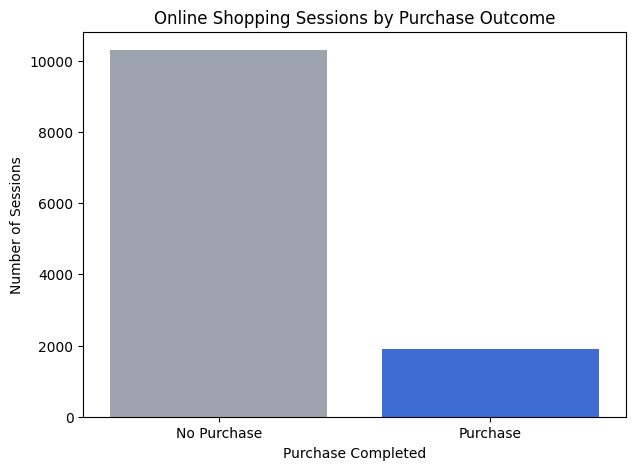

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Revenue",
    hue="Revenue",
    palette=["#9CA3AF", "#2563EB"],
    legend=False
)

plt.title("Online Shopping Sessions by Purchase Outcome")
plt.xlabel("Purchase Completed")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["No Purchase", "Purchase"])

plt.show()

In [20]:
df["VisitorType"].value_counts()

,count
VisitorType,
Returning_Visitor,10431
New_Visitor,1693
Other,81


In [22]:
visitor_analysis = (
    df.groupby("VisitorType")["Revenue"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

In [23]:
visitor_analysis.columns = [
    "VisitorType",
    "TotalSessions",
    "Purchases",
    "ConversionRate"
]

In [24]:
visitor_analysis["ConversionRate"] = (
    visitor_analysis["ConversionRate"] * 100
)

In [25]:
visitor_analysis

,VisitorType,TotalSessions,Purchases,ConversionRate
0,New_Visitor,1693,422,24.926167
1,Other,81,16,19.753086
2,Returning_Visitor,10431,1470,14.092609


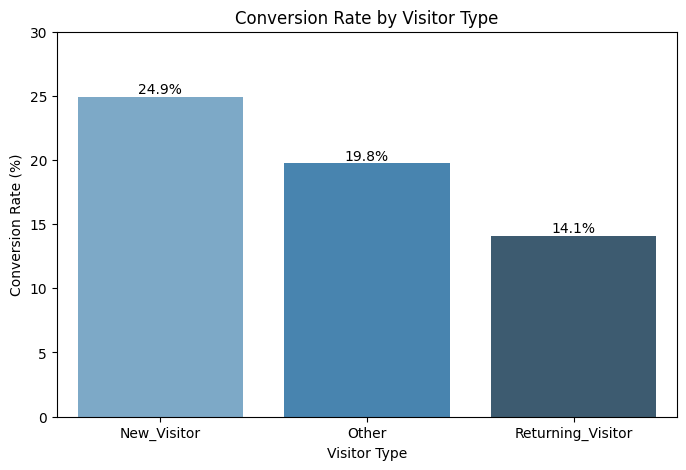

In [26]:
visitor_analysis = visitor_analysis.sort_values(
    "ConversionRate",
    ascending=False
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=visitor_analysis,
    x="VisitorType",
    y="ConversionRate",
    hue="VisitorType",
    palette="Blues_d",
    legend=False
)

plt.title("Conversion Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 30)
plt.show()

In [27]:
behavior_comparison = (
    df.groupby(["VisitorType", "Revenue"])[
        [
            "ProductRelated",
            "ProductRelated_Duration",
            "PageValues",
            "BounceRates",
            "ExitRates"
        ]
    ]
    .mean()
    .round(2)
    .reset_index()
)

behavior_comparison

,VisitorType,Revenue,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates
0,New_Visitor,False,16.66,557.93,1.37,0.01,0.02
1,New_Visitor,True,22.29,874.22,39.12,0.00,0.01
2,Other,False,10.22,436.16,1.56,0.04,0.07
3,Other,True,24.50,1258.39,90.33,0.00,0.01
4,Returning_Visitor,False,30.94,1162.14,2.09,0.03,0.05
5,Returning_Visitor,True,55.91,2170.58,23.17,0.01,0.02


In [28]:
behavior_comparison = (
    df.groupby(["VisitorType", "Revenue"])[
        [
            "ProductRelated",
            "ProductRelated_Duration",
            "PageValues",
            "BounceRates",
            "ExitRates"
        ]
    ]
    .mean()
    .round(2)
    .reset_index()
)

behavior_comparison

,VisitorType,Revenue,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates
0,New_Visitor,False,16.66,557.93,1.37,0.01,0.02
1,New_Visitor,True,22.29,874.22,39.12,0.00,0.01
2,Other,False,10.22,436.16,1.56,0.04,0.07
3,Other,True,24.50,1258.39,90.33,0.00,0.01
4,Returning_Visitor,False,30.94,1162.14,2.09,0.03,0.05
5,Returning_Visitor,True,55.91,2170.58,23.17,0.01,0.02


In [29]:
df["Month"].value_counts()

,count
Month,
May,3329
Nov,2982
Mar,1860
Dec,1706
Oct,549
Sep,448
Aug,433
Jul,432
June,285


In [31]:
monthly_analysis = (
    df.groupby("Month")["Revenue"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

In [33]:
monthly_analysis.columns = [
    "Month",
    "TotalSessions",
    "Purchases",
    "ConversionRate"
]

In [34]:
monthly_analysis["ConversionRate"] = (
    monthly_analysis["ConversionRate"] * 100
)

In [35]:
monthly_analysis.sort_values(
    "ConversionRate",
    ascending=False
)

,Month,TotalSessions,Purchases,ConversionRate
7,Nov,2982,760,25.486251
8,Oct,549,115,20.947177
9,Sep,448,86,19.196429
0,Aug,433,76,17.551963
3,Jul,432,66,15.277778
1,Dec,1706,216,12.661196
6,May,3329,365,10.964254
5,Mar,1860,192,10.322581
4,June,285,29,10.175439
2,Feb,181,3,1.657459


In [36]:
month_order = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_analysis["Month"] = pd.Categorical(
    monthly_analysis["Month"],
    categories=month_order,
    ordered=True
)

monthly_analysis = monthly_analysis.sort_values("Month")

monthly_analysis

,Month,TotalSessions,Purchases,ConversionRate
2,Feb,181,3,1.657459
5,Mar,1860,192,10.322581
6,May,3329,365,10.964254
4,June,285,29,10.175439
3,Jul,432,66,15.277778
0,Aug,433,76,17.551963
9,Sep,448,86,19.196429
8,Oct,549,115,20.947177
7,Nov,2982,760,25.486251
1,Dec,1706,216,12.661196


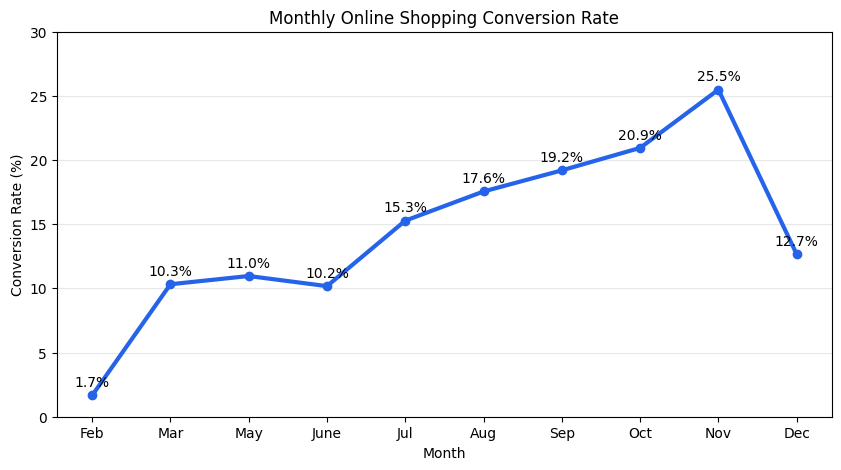

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["ConversionRate"],
    marker="o",
    linewidth=3,
    color="#2563EB"
)

for month, rate in zip(
    monthly_analysis["Month"],
    monthly_analysis["ConversionRate"]
):
    plt.text(
        month,
        rate + 0.7,
        f"{rate:.1f}%",
        ha="center"
    )

plt.title("Monthly Online Shopping Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 30)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [38]:
weekend_analysis = (
    df.groupby("Weekend")["Revenue"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

In [39]:
weekend_analysis.columns = [
    "Weekend",
    "TotalSessions",
    "Purchases",
    "ConversionRate"
]

In [40]:
weekend_analysis["DayType"] = weekend_analysis["Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekend_analysis["ConversionRate"] = (
    weekend_analysis["ConversionRate"] * 100
)

weekend_analysis

,Weekend,TotalSessions,Purchases,ConversionRate,DayType
0,False,9346,1409,15.075968,Weekday
1,True,2859,499,17.453655,Weekend


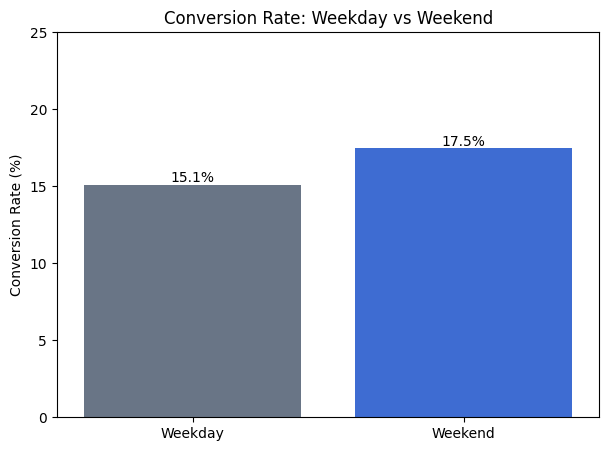

In [41]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=weekend_analysis,
    x="DayType",
    y="ConversionRate",
    hue="DayType",
    palette=["#64748B", "#2563EB"],
    legend=False
)

plt.title("Conversion Rate: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 25)
plt.show()

In [42]:
X = df.drop(columns=["Revenue", "PageValues"])
y = df["Revenue"].astype(int)

In [45]:
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Predictor shape: (12205, 16)
Target shape: (12205,)

Target values:
Revenue
0    10297
1     1908
Name: count, dtype: int64


In [46]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numerical_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay"
]

In [47]:
print("Categorical variables:", len(categorical_features))
print("Numerical variables:", len(numerical_features))
print("Total variables:", len(categorical_features) + len(numerical_features))

Categorical variables: 7
Numerical variables: 9
Total variables: 16


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("Training predictors:", X_train.shape)
print("Testing predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training predictors: (9764, 16)
Testing predictors: (2441, 16)
Training target: (9764,)
Testing target: (2441,)


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [54]:
StandardScaler()

StandardScaler()

In [55]:
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [56]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Prepared training shape:", X_train_prepared.shape)

print("Original testing shape:", X_test.shape)
print("Prepared testing shape:", X_test_prepared.shape)

Original training shape: (9764, 16)
Prepared training shape: (9764, 73)
Original testing shape: (2441, 16)
Prepared testing shape: (2441, 73)


In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

In [59]:
logistic_model.fit(
    X_train_prepared,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [60]:
logistic_predictions = logistic_model.predict(
    X_test_prepared
)

In [61]:
logistic_probabilities = logistic_model.predict_proba(
    X_test_prepared
)[:, 1]

In [63]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": logistic_predictions[:10],
    "PurchaseProbability": logistic_probabilities[:10]
})

prediction_preview

,Actual,Predicted,PurchaseProbability
0,0,1,0.538687
1,0,1,0.801175
2,0,1,0.543054
3,0,0,0.464698
4,0,0,0.008851
5,0,1,0.913069
6,0,0,0.025338
7,0,0,0.350661
8,0,1,0.541886
9,0,0,0.162018


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [65]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

In [66]:
print(f"Accuracy:  {logistic_accuracy:.2%}")
print(f"Precision: {logistic_precision:.2%}")
print(f"Recall:    {logistic_recall:.2%}")
print(f"F1-score:  {logistic_f1:.2%}")
print(f"ROC-AUC:   {logistic_roc_auc:.2%}")

Accuracy:  64.93%
Precision: 27.89%
Recall:    78.27%
F1-score:  41.13%
ROC-AUC:   75.55%


In [67]:
from sklearn.metrics import confusion_matrix

In [68]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_cm

array([[1286,  773],
       [  83,  299]])

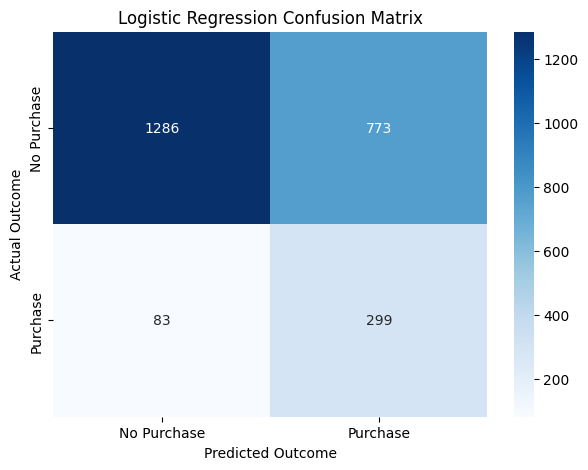

In [69]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

In [72]:
decision_tree_model.fit(
    X_train_prepared,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=20, random_state=42)

In [73]:
tree_predictions = decision_tree_model.predict(
    X_test_prepared
)

tree_probabilities = decision_tree_model.predict_proba(
    X_test_prepared
)[:, 1]

In [74]:
tree_accuracy = accuracy_score(
    y_test, tree_predictions
)

tree_precision = precision_score(
    y_test, tree_predictions
)

tree_recall = recall_score(
    y_test, tree_predictions
)

tree_f1 = f1_score(
    y_test, tree_predictions
)

tree_roc_auc = roc_auc_score(
    y_test, tree_probabilities
)

In [75]:
print(f"Accuracy:  {tree_accuracy:.2%}")
print(f"Precision: {tree_precision:.2%}")
print(f"Recall:    {tree_recall:.2%}")
print(f"F1-score:  {tree_f1:.2%}")
print(f"ROC-AUC:   {tree_roc_auc:.2%}")

Accuracy:  66.78%
Precision: 27.21%
Recall:    67.02%
F1-score:  38.70%
ROC-AUC:   72.65%


In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_prepared,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=4, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [78]:
forest_predictions = random_forest_model.predict(
    X_test_prepared
)

forest_probabilities = random_forest_model.predict_proba(
    X_test_prepared
)[:, 1]

In [79]:
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_precision = precision_score(y_test, forest_predictions)
forest_recall = recall_score(y_test, forest_predictions)
forest_f1 = f1_score(y_test, forest_predictions)
forest_roc_auc = roc_auc_score(y_test, forest_probabilities)

In [80]:
print(f"Accuracy:  {forest_accuracy:.2%}")
print(f"Precision: {forest_precision:.2%}")
print(f"Recall:    {forest_recall:.2%}")
print(f"F1-score:  {forest_f1:.2%}")
print(f"ROC-AUC:   {forest_roc_auc:.2%}")

Accuracy:  72.88%
Precision: 31.28%
Recall:    61.26%
F1-score:  41.42%
ROC-AUC:   78.21%


In [81]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ],
    "ROCAUC": [
        logistic_roc_auc,
        tree_roc_auc,
        forest_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC
0,Logistic Regression,0.649324,0.278918,0.782723,0.411279,0.755511
1,Decision Tree,0.667759,0.272051,0.670157,0.386999,0.726549
2,Random Forest,0.728800,0.312834,0.612565,0.414159,0.782105


In [82]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

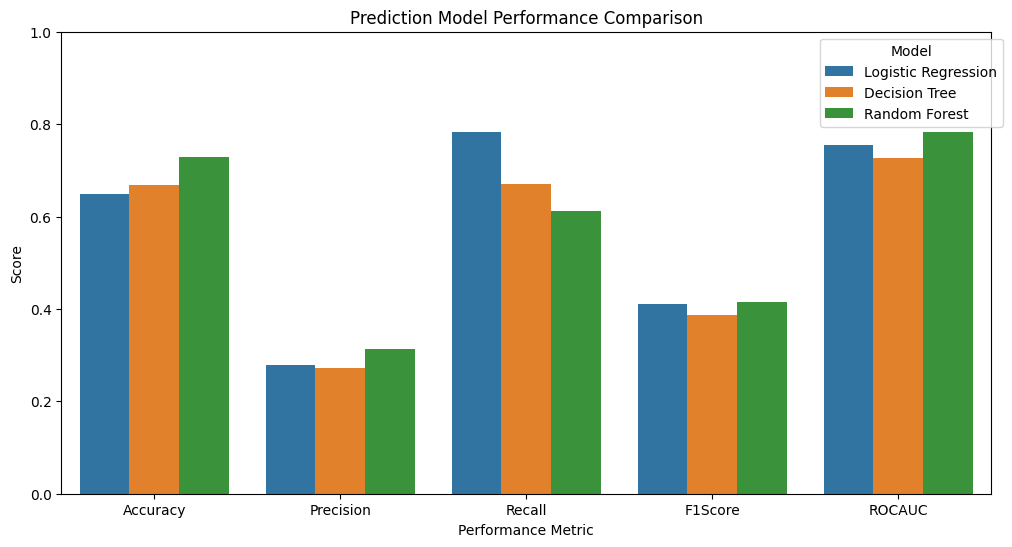

In [83]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Prediction Model Performance Comparison")
plt.xlabel("Performance Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1))

plt.show()

In [84]:
feature_names = preprocessor.get_feature_names_out()

In [85]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

In [86]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [87]:
top_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

top_features

,Feature,Importance
7,ExitRates,0.177841
5,ProductRelated_Duration,0.141753
4,ProductRelated,0.096508
6,BounceRates,0.090748
1,Administrative_Duration,0.067126
0,Administrative,0.060148
16,Month_Nov,0.040828
3,Informational_Duration,0.024305
70,VisitorType_Returning_Visitor,0.019693
2,Informational,0.017898


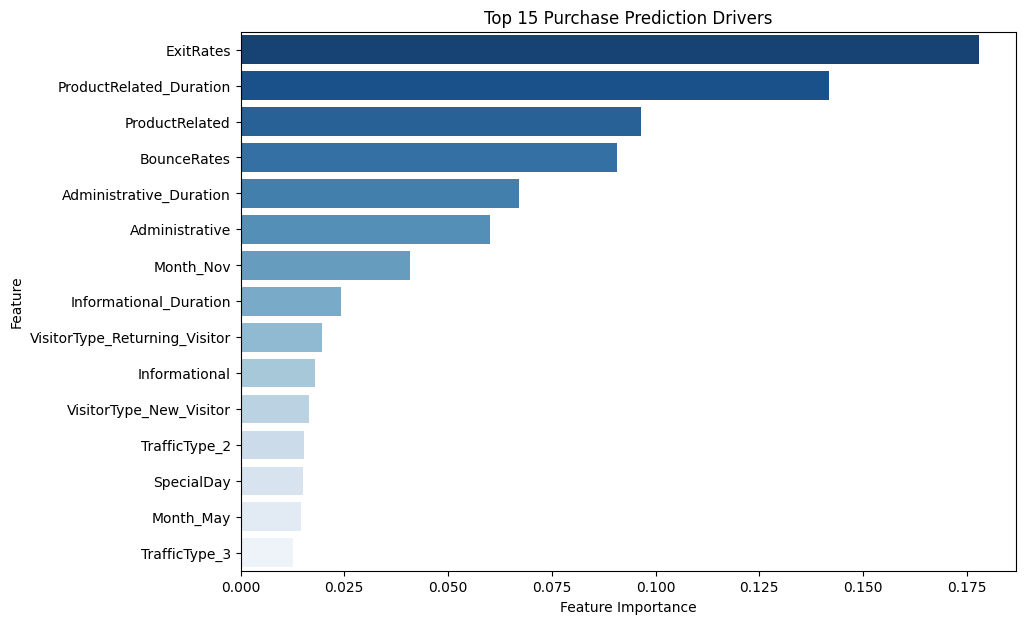

In [88]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="Blues_r",
    legend=False
)

plt.title("Top 15 Purchase Prediction Drivers")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [101]:
import numpy as np

powerbi_results = df.loc[X_test.index].copy()

powerbi_results["ActualPurchase"] = np.where(
    y_test.values == 1,
    "Purchase",
    "No Purchase"
)

powerbi_results["PredictedPurchase"] = np.where(
    forest_predictions == 1,
    "Purchase",
    "No Purchase"
)

powerbi_results["PurchaseProbability"] = forest_probabilities

powerbi_results["PredictionResult"] = np.where(
    y_test.values == forest_predictions,
    "Correct",
    "Incorrect"
)

powerbi_results["ProbabilityBand"] = pd.cut(
    powerbi_results["PurchaseProbability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

In [102]:
print(powerbi_results.columns.tolist())

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue', 'ActualPurchase', 'PredictedPurchase', 'PurchaseProbability', 'PredictionResult', 'ProbabilityBand']


In [103]:
powerbi_results[
    [
        "ActualPurchase",
        "PredictedPurchase",
        "PurchaseProbability",
        "PredictionResult",
        "ProbabilityBand"
    ]
].head(10)

,ActualPurchase,PredictedPurchase,PurchaseProbability,PredictionResult,ProbabilityBand
11640,No Purchase,No Purchase,0.264343,Correct,Low
6936,No Purchase,Purchase,0.540363,Incorrect,Medium
7194,No Purchase,Purchase,0.557465,Incorrect,Medium
11263,No Purchase,No Purchase,0.448373,Correct,Medium
4728,No Purchase,No Purchase,0.015704,Correct,Low
9878,No Purchase,Purchase,0.753194,Incorrect,High
8101,No Purchase,No Purchase,0.135932,Correct,Low
6642,No Purchase,No Purchase,0.367574,Correct,Medium
10215,No Purchase,No Purchase,0.234173,Correct,Low
10224,No Purchase,No Purchase,0.159902,Correct,Low


In [104]:
conditions = [
    (powerbi_results["ActualPurchase"] == "Purchase") &
    (powerbi_results["PredictedPurchase"] == "Purchase"),

    (powerbi_results["ActualPurchase"] == "No Purchase") &
    (powerbi_results["PredictedPurchase"] == "No Purchase"),

    (powerbi_results["ActualPurchase"] == "No Purchase") &
    (powerbi_results["PredictedPurchase"] == "Purchase"),

    (powerbi_results["ActualPurchase"] == "Purchase") &
    (powerbi_results["PredictedPurchase"] == "No Purchase")
]

categories = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

powerbi_results["ConfusionCategory"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

In [105]:
powerbi_results["ConfusionCategory"].value_counts()

,count
ConfusionCategory,
True Negative,1545
False Positive,514
True Positive,234
False Negative,148


In [106]:
(powerbi_results["ConfusionCategory"] == "Unknown").sum()

np.int64(0)

In [107]:
powerbi_results.to_csv(
    "powerbi_scored_sessions.csv",
    index=False
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

top_features.to_csv(
    "feature_importance.csv",
    index=False
)

In [108]:
import os

print("Scored sessions:", os.path.exists("powerbi_scored_sessions.csv"))
print("Model comparison:", os.path.exists("model_comparison.csv"))
print("Feature importance:", os.path.exists("feature_importance.csv"))

Scored sessions: True
Model comparison: True
Feature importance: True
